Part 1: Data Preprocessing

In [48]:
import numpy as np
import pandas as pd
import seaborn as sns

# Load dataset
df = sns . load_dataset ('diamonds')
# Inject missing values for the assignment
np . random . seed (42)
mask_carat = np . random . rand (len ( df ) ) < 0.05
mask_price = np . random . rand (len ( df ) ) < 0.05

df . loc [ mask_carat , 'carat'] = np . nan
df . loc [ mask_price , 'price'] = np . nan

Task 1: Dataset Inspection & Invalid Value Cleaning

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    51254 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    51270 non-null  float64 
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(7)
memory usage: 3.0 MB


In [50]:
df.describe()

,carat,depth,table,price,x,y,z
count,51254.000000,53940.000000,53940.000000,51270.000000,53940.000000,53940.000000,53940.000000
mean,0.798132,61.749405,57.457184,3937.102204,5.731157,5.734526,3.538734
std,0.473675,1.432621,2.234491,3992.384510,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,952.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2403.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5327.000000,6.540000,6.540000,4.040000
max,4.500000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [51]:
df.shape

(53940, 10)

In [52]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nMissing percentage (%):")
print((df.isnull().mean() * 100).round(2))

Missing values per column:
carat      2686
cut           0
color         0
clarity       0
depth         0
table         0
price      2670
x             0
y             0
z             0
dtype: int64

Missing percentage (%):
carat      4.98
cut        0.00
color      0.00
clarity    0.00
depth      0.00
table      0.00
price      4.95
x          0.00
y          0.00
z          0.00
dtype: float64


In [53]:
print("rows counthaving x == 0, y == 0, or z == 0, which are invalid values for a diamond's dimensions.")
print(len(df[df['x']==0]))
print(len(df[df['y']==0]))
print(len(df[df['z']==0]))

df['x'].replace(0, np.nan, inplace=True)
df['y'].replace(0, np.nan, inplace=True)
df['z'].replace(0, np.nan, inplace=True)
print("rows count having missing values in x, y, or z after replacing 0 with NaN.")
print(df['x'].isnull().sum())
print(df['y'].isnull().sum())
print(df['z'].isnull().sum())

rows counthaving x == 0, y == 0, or z == 0, which are invalid values for a diamond's dimensions.
8
7
20
rows count having missing values in x, y, or z after replacing 0 with NaN.
8
7
20


C:\Users\USERAS\AppData\Local\Temp\ipykernel_23252\1052428911.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['x'].replace(0, np.nan, inplace=True)
C:\Users\USERAS\AppData\Local\Temp\ipykernel_23252\1052428911.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [54]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nMissing percentage (%):")
print((df.isnull().mean() * 100).round(2))

Missing values per column:
carat      2686
cut           0
color         0
clarity       0
depth         0
table         0
price      2670
x             8
y             7
z            20
dtype: int64

Missing percentage (%):
carat      4.98
cut        0.00
color      0.00
clarity    0.00
depth      0.00
table      0.00
price      4.95
x          0.01
y          0.01
z          0.04
dtype: float64


Task 2: Missing Value Imputation

In [55]:
df['carat'] = df['carat'].fillna(df['carat'].median())
df['price'] = df['price'].fillna(df['price'].median())



In [56]:
print(df['cut'].unique())


['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']


In [57]:
for col in ['x','y','z']:
    df[col] = df[col].fillna(
        df.groupby('cut')[col].transform('median')
    )


print(df[['x', 'y', 'z']].isnull().sum())
df.isnull().sum()

x    0
y    0
z    0
dtype: int64


C:\Users\USERAS\AppData\Local\Temp\ipykernel_23252\3035432964.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('cut')[col].transform('median')


carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Task 3: Categorical Feature Encoding

In [58]:
print(df['cut'].unique())
print(df['color'].unique())
print(df['clarity'].unique())

['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']


In [59]:
cut_map = {
    'Fair':0,
    'Good':1,
    'Very Good':2,
    'Premium':3,
    'Ideal':4
}

clarity_map = {
    'I1':0,
    'SI2':1,
    'SI1':2,
    'VS2':3,
    'VS1':4,
    'VVS2':5,
    'VVS1':6,
    'IF':7
}


df['cut'] = df['cut'].map(cut_map)

df['clarity'] = df['clarity'].map(clarity_map)

print(df.head())

   carat cut color clarity  depth  table  price     x     y     z
0   0.23   4     E       1   61.5   55.0  326.0  3.95  3.98  2.43
1   0.21   3     E       2   59.8   61.0  326.0  3.89  3.84  2.31
2   0.23   1     E       4   56.9   65.0  327.0  4.05  4.07  2.31
3   0.29   3     I       3   62.4   58.0  334.0  4.20  4.23  2.63
4   0.31   1     J       1   63.3   58.0  335.0  4.34  4.35  2.75


In [60]:
df = pd.get_dummies(df,columns=['color'],prefix='color',dtype=int)

df.head()

,carat,cut,clarity,depth,table,price,x,y,z,color_D,color_E,color_F,color_G,color_H,color_I,color_J
0,0.23,4,1,61.5,55.0,326.0,3.95,3.98,2.43,0,1,0,0,0,0,0
1,0.21,3,2,59.8,61.0,326.0,3.89,3.84,2.31,0,1,0,0,0,0,0
2,0.23,1,4,56.9,65.0,327.0,4.05,4.07,2.31,0,1,0,0,0,0,0
3,0.29,3,3,62.4,58.0,334.0,4.20,4.23,2.63,0,0,0,0,0,1,0
4,0.31,1,1,63.3,58.0,335.0,4.34,4.35,2.75,0,0,0,0,0,0,1


Task 4: Outlier Detection & Capping (Winsorization)

In [61]:
Q1 = df['table'].quantile(0.25)
Q3 = df['table'].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

print(Q1,Q3,IQR)
print()
print(lower,upper)

56.0 59.0 3.0

51.5 63.5


In [62]:
outliers = df[(df['table'] < lower) | (df['table'] > upper)]

print(len(outliers))

605


In [63]:
df['table_capped'] = df['table'].clip(lower=lower, upper=upper)

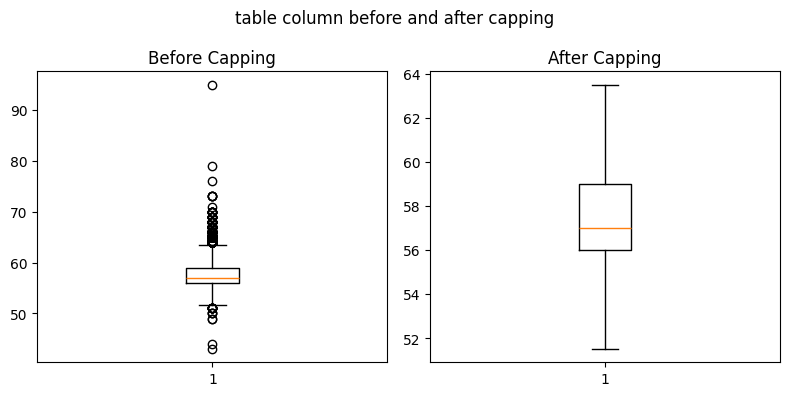

In [64]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(1,2,figsize=(8,4))
fig.suptitle("table column before and after capping")
ax[0].boxplot(df['table'])
ax[0].set_title("Before Capping")

ax[1].boxplot(df['table_capped'])
ax[1].set_title("After Capping")

plt.tight_layout()
plt.show()

Task 5: Train/Test Split & Data Scaling

In [65]:
from sklearn.model_selection import train_test_split


X = df.drop('price',axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(43152, 16)
(10788, 16)
(43152,)
(10788,)


In [66]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'carat',
    'depth',
    'table',
    'x',
    'y',
    'z'
]
scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])

X_test[scale_cols] = scaler.transform(X_test[scale_cols])


We only fit the scaler on training data. If we used the whole dataset, information from the test set would leak into the scaling process.

Task 6: Univariate Analysis & Target Transformation

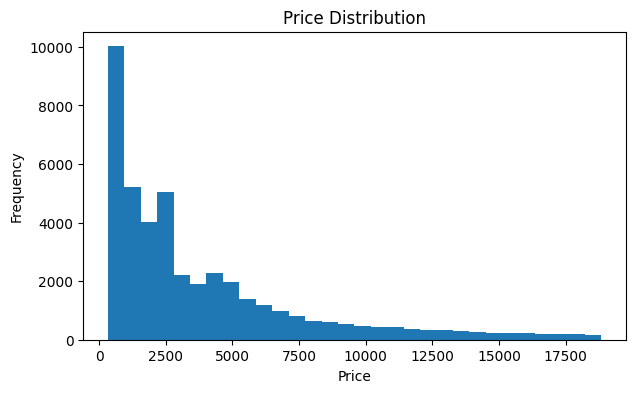

In [67]:
plt.figure(figsize=(7,4))

plt.hist( y_train, bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

It is right-skewed.

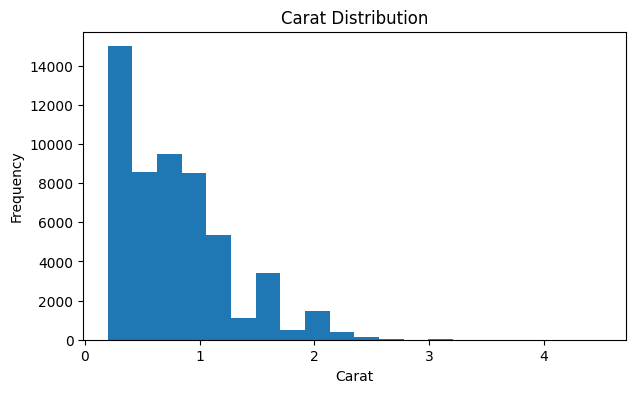

In [68]:
plt.figure(figsize=(7,4))
plt.hist(df['carat'],bins=20)
plt.title("Carat Distribution")
plt.xlabel("Carat")
plt.ylabel("Frequency")
plt.show()

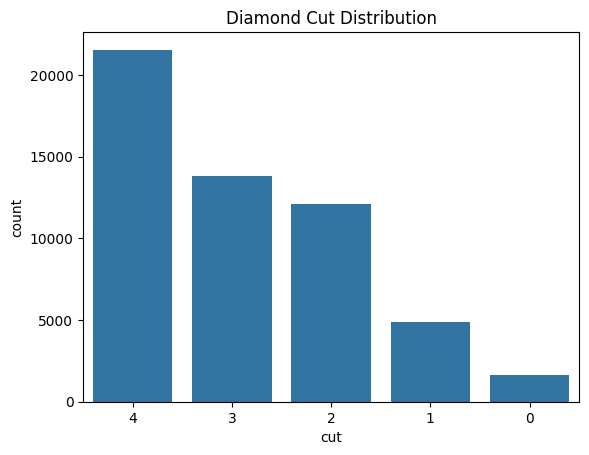

In [69]:
sns.countplot(x=df['cut'])
plt.title("Diamond Cut Distribution")
plt.show()

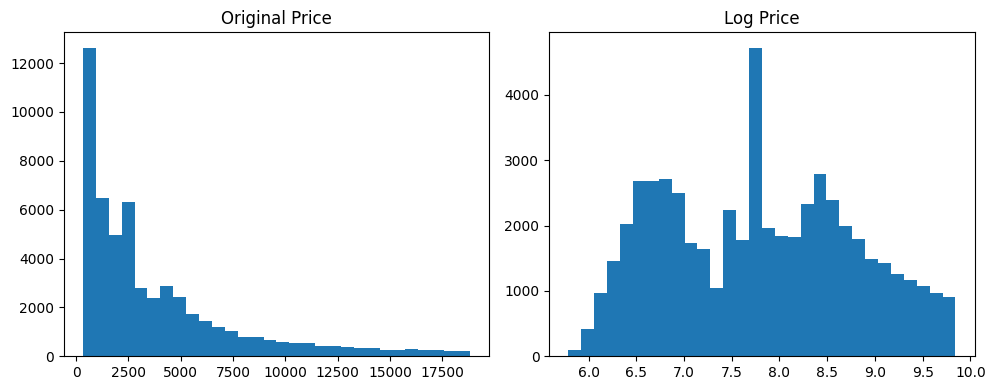

In [70]:
df['log_price'] = np.log1p(df['price'])

fig,ax=plt.subplots(1,2,figsize=(10,4))

ax[0].hist(df['price'],bins=30)
ax[0].set_title("Original Price")

ax[1].hist(df['log_price'],bins=30)
ax[1].set_title("Log Price")

plt.tight_layout()
plt.show()

Log transformation reduces right skewness and makes the distribution closer to symmetric.

Task 7: Bivariate Analysis

In [71]:
print(df.groupby('cut')['price'].mean())

cut
4    3407.728458
3    4487.753245
2    3898.355156
1    3857.608439
0    4295.232919
Name: price, dtype: float64


C:\Users\USERAS\AppData\Local\Temp\ipykernel_23252\558509494.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('cut')['price'].mean())


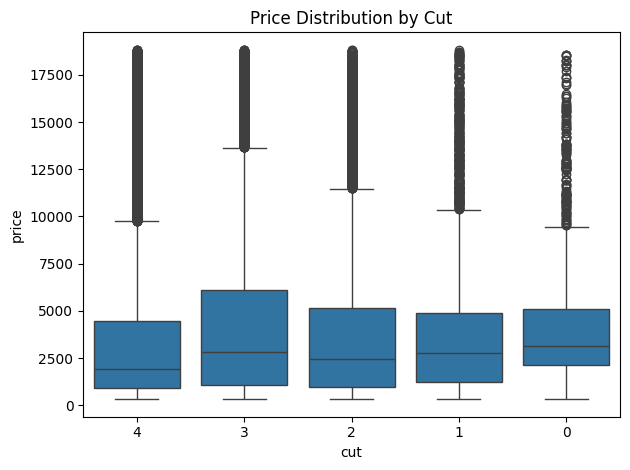

In [72]:
sns.boxplot(x='cut',y='price',data=df)
plt.title("Price Distribution by Cut")
plt.tight_layout()
plt.show()

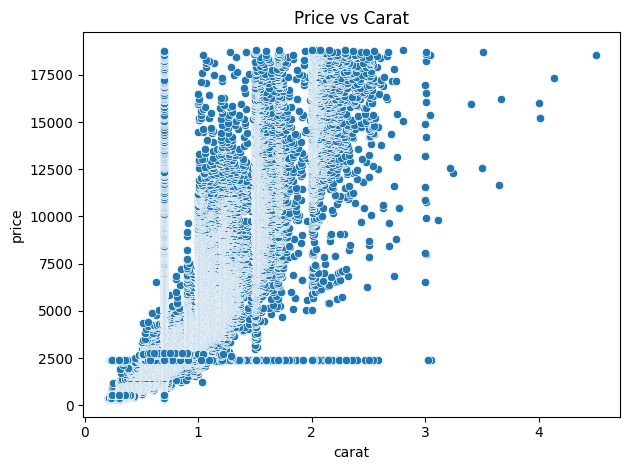

In [73]:
sns.scatterplot(x='carat',y='price',data=df)
plt.title("Price vs Carat")
plt.tight_layout()
plt.show()

Task 8: Correlation Analysis & Heatmap

In [77]:
cd = X_train.copy()
cd['price'] = y_train
matrix = cd.corr()
print(matrix)

                 carat       cut   clarity     depth     table         x  \
carat         1.000000 -0.134422 -0.343695  0.033428  0.174779  0.952330   
cut          -0.134422  1.000000  0.186526 -0.214257 -0.434313 -0.127773   
clarity      -0.343695  0.186526  1.000000 -0.065298 -0.157548 -0.371950   
depth         0.033428 -0.214257 -0.065298  1.000000 -0.298664 -0.021658   
table         0.174779 -0.434313 -0.157548 -0.298664  1.000000  0.193311   
x             0.952330 -0.127773 -0.371950 -0.021658  0.193311  1.000000   
y             0.923946 -0.122678 -0.356250 -0.025974  0.180451  0.969136   
z             0.932220 -0.150895 -0.367180  0.098010  0.148430  0.971322   
color_D      -0.107871  0.008253 -0.084838 -0.013746 -0.011143 -0.105007   
color_E      -0.138533 -0.001959 -0.022023 -0.031490  0.005121 -0.136467   
color_F      -0.058326 -0.010181  0.024833 -0.017256 -0.003702 -0.047715   
color_G      -0.028168  0.044181  0.130116  0.003215 -0.040478 -0.024719   
color_H     

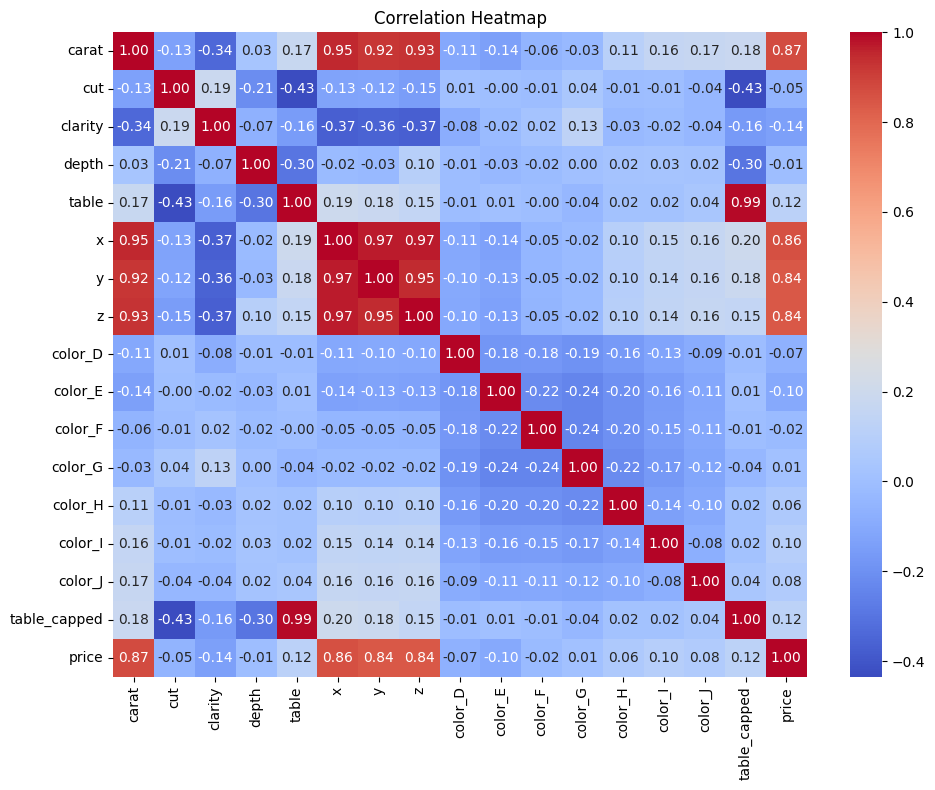

In [78]:
plt.figure(figsize=(10,8))
sns.heatmap(matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Carat has the strongest positive correlation with price with the highest correlation value of 0.87